# 06 — Mesh graph nets and transient surrogates

Two capabilities aimed squarely at multiphysics practice:

- **Part A**: graph neural networks operating **directly on the unstructured mesh**
  (`physicsnemo.models.meshgraphnet.MeshGraphNet`) — FEM's native representation,
  no voxelization loss.
- **Part B**: an **autoregressive transient surrogate** predicting the next time
  step from a rolling history, deployed with `TimeSeriesInferenceProcess`.

> **Prerequisites**: a compiled Kratos with `PhysicsNeMoApplication` enabled and, on the
> environment running this notebook:
>
> ```bash
> export PYTHONPATH=/path/to/Kratos/bin/Release
> export LD_LIBRARY_PATH=/path/to/Kratos/bin/Release/libs:$LD_LIBRARY_PATH
> pip install torch nvidia-physicsnemo          # optional runtime dependencies
> pip install torch_geometric torch_scatter     # additionally needed for MeshGraphNet (Part A)
> ```
>
> Everything below runs on CPU; outputs are written to `./output/`.

In [1]:
import math
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
from KratosMultiphysics.PhysicsNeMoApplication import graph_bridge
from KratosMultiphysics.PhysicsNeMoApplication import graph_inference_process
from KratosMultiphysics.PhysicsNeMoApplication import time_series_inference_process

torch.manual_seed(0)
numpy.random.seed(0)
Path("output").mkdir(exist_ok=True)

## Part A — The mesh as a graph

A structured tetrahedral mesh of the unit cube; `graph_bridge.BuildGraph` extracts the
element-edge graph (true geometry edges, both directions) and the standard
MeshGraphNet edge features (relative position + distance).

In [2]:
_HEX_TO_TETS = ((0, 1, 2, 6), (0, 2, 3, 6), (0, 3, 7, 6), (0, 7, 4, 6), (0, 4, 5, 6), (0, 5, 1, 6))

def create_structured_tet_model_part(model, name, divisions, variables):
    model_part = model.CreateModelPart(name)
    for variable in variables:
        model_part.AddNodalSolutionStepVariable(variable)
    props = model_part.CreateNewProperties(1)
    n = divisions + 1
    node_id = 0
    for i in range(n):
        for j in range(n):
            for k in range(n):
                node_id += 1
                model_part.CreateNewNode(node_id, i / divisions, j / divisions, k / divisions)
    def nid(i, j, k):
        return i * n * n + j * n + k + 1
    element_id = 0
    for i in range(divisions):
        for j in range(divisions):
            for k in range(divisions):
                corners = [nid(i, j, k), nid(i+1, j, k), nid(i+1, j+1, k), nid(i, j+1, k),
                           nid(i, j, k+1), nid(i+1, j, k+1), nid(i+1, j+1, k+1), nid(i, j+1, k+1)]
                for tet in _HEX_TO_TETS:
                    element_id += 1
                    model_part.CreateNewElement("Element3D4N", element_id, [corners[c] for c in tet], props)
    return model_part

model = Kratos.Model()
mesh_part = create_structured_tet_model_part(model, "Graph", 3, [Kratos.DISPLACEMENT, Kratos.PRESSURE, Kratos.TEMPERATURE])
for node in mesh_part.Nodes:
    node.SetSolutionStepValue(Kratos.DISPLACEMENT, [node.X, node.Y, node.Z])
    node.SetSolutionStepValue(Kratos.PRESSURE, math.sin(math.pi * node.X) * math.cos(math.pi * node.Y) * node.Z)

node_features, edge_index, edge_features, node_ids = graph_bridge.BuildGraph(
    mesh_part, [("DISPLACEMENT", "node_historical")])
print(f"{len(node_ids)} nodes, {edge_index.shape[1]} directed edges, "
      f"node features {node_features.shape}, edge features {edge_features.shape}")

64 nodes, 558 directed edges, node features (64, 3), edge features (558, 4)


## Training a small MeshGraphNet

Task: regress the smooth pressure field from nodal coordinates (packed into
`DISPLACEMENT` as node features). The graph object is a
`torch_geometric.data.Data` built by `graph_bridge.ToPyGGraph`.

final loss: 9.635009337216616e-05


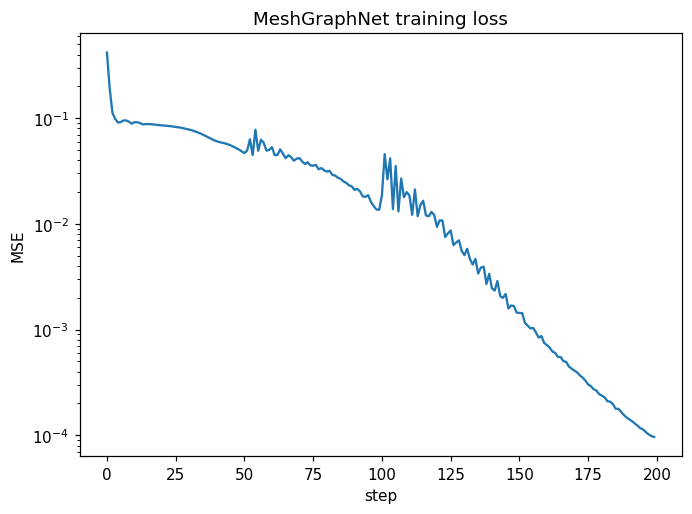

In [3]:
from physicsnemo.models.meshgraphnet import MeshGraphNet

graph = graph_bridge.ToPyGGraph(edge_index, len(node_ids))
target = torch.tensor(
    [[mesh_part.GetNode(int(nid)).GetSolutionStepValue(Kratos.PRESSURE)] for nid in node_ids],
    dtype=torch.float32)
inputs = torch.from_numpy(node_features).float()
edges = torch.from_numpy(edge_features).float()

mgn = MeshGraphNet(input_dim_nodes=3, input_dim_edges=4, output_dim=1,
                   processor_size=4, hidden_dim_processor=32,
                   hidden_dim_node_encoder=32, hidden_dim_edge_encoder=32,
                   hidden_dim_node_decoder=32)
optimizer = torch.optim.Adam(mgn.parameters(), lr=2e-3)

losses = []
for step in range(200):
    optimizer.zero_grad()
    loss = torch.nn.functional.mse_loss(mgn(inputs, edges, graph), target)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.semilogy(losses); plt.xlabel("step"); plt.ylabel("MSE"); plt.title("MeshGraphNet training loss")
plt.tight_layout(); plt.savefig("output/mgn_loss.png", dpi=120); plt.show()
print("final loss:", losses[-1])
mgn.save("output/meshgraphnet.mdlus")

## Deploying with GraphInferenceProcess

The process extracts the graph once, gathers node features each step and writes the
prediction back — here into `TEMPERATURE`, compared against the exact field.

In [4]:
settings = Kratos.Parameters("""{
    "Parameters": {
        "model_part_name" : "Graph",
        "model_settings"  : {
            "checkpoint_file" : "output/meshgraphnet.mdlus",
            "checkpoint_type" : "physicsnemo",
            "device"          : "auto"
        },
        "input_fields"    : [ { "variable_name" : "DISPLACEMENT", "data_location" : "node_historical" } ],
        "output_fields"   : [ { "variable_name" : "TEMPERATURE",  "data_location" : "node_historical" } ]
    }
}""")
process = graph_inference_process.Factory(settings, model)
process.ExecuteInitialize()
mesh_part.ProcessInfo[Kratos.STEP] = 1
process.ExecuteFinalizeSolutionStep()

predicted = numpy.array([node.GetSolutionStepValue(Kratos.TEMPERATURE) for node in mesh_part.Nodes])
exact = numpy.array([node.GetSolutionStepValue(Kratos.PRESSURE) for node in mesh_part.Nodes])
print(f"GNN regression RMSE on the mesh: {numpy.sqrt(numpy.mean((predicted - exact)**2)):.4f}")

GNN regression RMSE on the mesh: 0.0097


## Part B — Autoregressive transient surrogate

A damped travelling wave `u(x, t) = e^{-t/2} · sin(π x − t)` sampled on a line of
nodes. A small MLP learns to map the last K = 2 states to the next one; the
`TimeSeriesInferenceProcess` then rolls it forward inside a (fake) time loop.

In [5]:
N_NODES, DT = 41, 0.1

def wave(x, t):
    return math.exp(-0.5 * t) * math.sin(math.pi * x - t)

ts_model = Kratos.Model()
line = ts_model.CreateModelPart("Line")
line.AddNodalSolutionStepVariable(Kratos.PRESSURE)
line.AddNodalSolutionStepVariable(Kratos.TEMPERATURE)
for i in range(N_NODES):
    line.CreateNewNode(i + 1, i / (N_NODES - 1), 0.0, 0.0)
xs = numpy.array([node.X for node in line.Nodes])

# Training windows from the analytic trajectory: (u_{t-1}, u_t) -> u_{t+1}
steps = numpy.arange(0, 60)
trajectory = numpy.stack([[wave(x, t * DT) for x in xs] for t in steps])  # (T, N)
windows = numpy.stack([numpy.concatenate([trajectory[t - 1, :, None], trajectory[t, :, None]], axis=1)
                       for t in range(1, len(steps) - 1)])                # (T-2, N, 2)
targets = trajectory[2:][:, :, None]                                       # (T-2, N, 1)

inputs_t = torch.from_numpy(windows.reshape(-1, 2)).float()
targets_t = torch.from_numpy(targets.reshape(-1, 1)).float()

step_net = torch.nn.Sequential(
    torch.nn.Linear(2, 32), torch.nn.Tanh(),
    torch.nn.Linear(32, 32), torch.nn.Tanh(),
    torch.nn.Linear(32, 1))
optimizer = torch.optim.Adam(step_net.parameters(), lr=2e-3)
for epoch in range(400):
    optimizer.zero_grad()
    loss = torch.nn.functional.mse_loss(step_net(inputs_t), targets_t)
    loss.backward()
    optimizer.step()
print("time-stepper final loss:", loss.item())
torch.jit.script(step_net).save("output/step_net.pt")

time-stepper final loss: 1.3790510820399504e-05


## Rolling the surrogate forward

The process warms up its history for K−1 steps, then predicts each next state into
`TEMPERATURE` while the "solver" (the analytic field) advances `PRESSURE`.

probe-node RMSE over the trajectory: 4.5420e-03


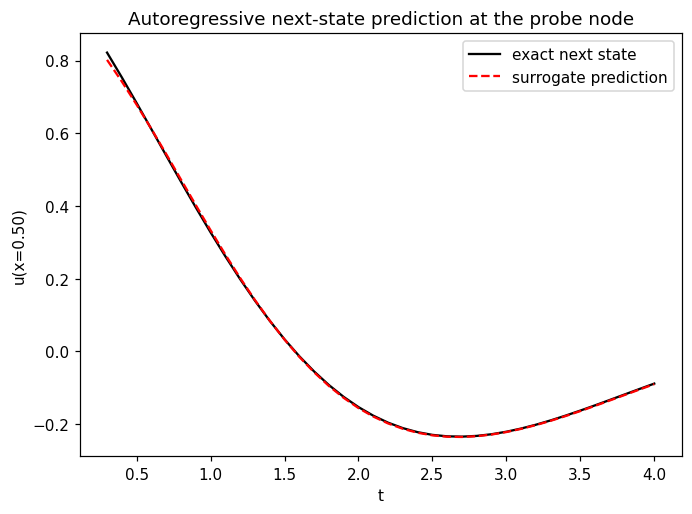

In [6]:
settings = Kratos.Parameters("""{
    "Parameters": {
        "model_part_name" : "Line",
        "model_settings"  : { "checkpoint_file" : "output/step_net.pt", "device" : "auto" },
        "input_fields"    : [ { "variable_name" : "PRESSURE",    "data_location" : "node_historical" } ],
        "output_fields"   : [ { "variable_name" : "TEMPERATURE", "data_location" : "node_historical" } ],
        "history_size"    : 2
    }
}""")
ts_process = time_series_inference_process.Factory(settings, ts_model)

probe = line.GetNode(21)  # midpoint
predicted_history, exact_history, times = [], [], []
for step in range(1, 40):
    t = step * DT
    line.ProcessInfo[Kratos.STEP] = step
    for node in line.Nodes:
        node.SetSolutionStepValue(Kratos.PRESSURE, wave(node.X, t))
    ts_process.ExecuteFinalizeSolutionStep()
    if step >= 2:  # history full from step 2 onwards
        times.append(t + DT)
        predicted_history.append(probe.GetSolutionStepValue(Kratos.TEMPERATURE))
        exact_history.append(wave(probe.X, t + DT))

plt.plot(times, exact_history, "k-", label="exact next state")
plt.plot(times, predicted_history, "r--", label="surrogate prediction")
plt.xlabel("t"); plt.ylabel(f"u(x={probe.X:.2f})"); plt.legend()
plt.title("Autoregressive next-state prediction at the probe node")
plt.tight_layout(); plt.savefig("output/time_series.png", dpi=120); plt.show()

rmse = numpy.sqrt(numpy.mean((numpy.array(predicted_history) - numpy.array(exact_history))**2))
print(f"probe-node RMSE over the trajectory: {rmse:.4e}")

## Where to go from here

- Feed real transient Kratos results (exported with `DatasetExportProcess`) into the
  same window/target construction to train production time-steppers.
- For the GNN path, scale MeshGraphNet up and train on `MeshExportProcess` series —
  the graph is rebuilt per mesh, so varying topologies across samples are fine.
- Set `"update_edge_features": true` in `GraphInferenceProcess` for ALE/moving-mesh
  problems so edge encodings follow the deforming geometry.